In [1]:
from data_augmentation.generator.noisy_matrices_generator import NoisyMatricesGenerator
from data_augmentation.generator.coherent_matrices_generator import CoherentMatricesGenerator
from data_augmentation.generator.target_cr_generator import TargetCRMatricesGenerator
from data_augmentation.data_loader import DataLoader
from visualization.data.matrices_visualizator import MatricesVisualizator
from analytic_methods.EVM_method import EVM
from metrics.evaluator import Evaluator
import numpy as np

### Generating all matrices 

In [3]:
MATRICES_NUM = 10
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.4]
NOISY_RATES = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.4]

In [3]:
coherent_generator = CoherentMatricesGenerator(MATRICES_NUM, CRITERIA_NUM)

matrix_coh, weights_coh = coherent_generator.generate_uniform()
coherent_generator.save_state(is_uniform=True)
matrix_coh, weights_coh = coherent_generator.generate_uniform()
coherent_generator.save_state(is_uniform=False)

alpha = [10.0 for i in range(CRITERIA_NUM)]
for rate in NOISY_RATES:
    noisy_generator = NoisyMatricesGenerator(MATRICES_NUM, CRITERIA_NUM, rate)

    matrix_noisy, weigths_noisy = noisy_generator.generate_uniform()
    noisy_generator.save_state(is_uniform=True)
    matrix_noisy, weigths_noisy = noisy_generator.generate_dirichlet(alpha)
    noisy_generator.save_state(is_uniform=False)

for cr in CONSISTENCY_RATES:
    target_cr_generator = TargetCRMatricesGenerator(MATRICES_NUM, CRITERIA_NUM, target_cr=cr, tolerance=0.001)

    matrix_noisy, weigths_noisy = target_cr_generator.generate_uniform()
    target_cr_generator.save_state(is_uniform=True)
    matrix_noisy, weigths_noisy = target_cr_generator.generate_dirichlet(alpha)
    target_cr_generator.save_state(is_uniform=False)

Coherent matrices and weights have been saved in: data/synthetic_data/coherent/uniform
Coherent matrices and weights have been saved in: data/synthetic_data/coherent/dirichlet
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/uniform
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/dirichlet
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/uniform
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/dirichlet
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/uniform
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/dirichlet
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/uniform
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/dirichlet
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/uniform
Noisy matrices and weights have been saved in: data/synthetic_data/noisy/dirichlet
Nois

### Loading data

In [5]:
loader = DataLoader()

matrices_coh_uni, weights_coh_uni = loader.load_coherent_matrices(is_uniform=True)
matrices_coh_diri, weights_coh_diri = loader.load_coherent_matrices(is_uniform=False)

uni_noisy_matrices_list = []
uni_noisy_weights_list = []
diri_noisy_matrices_list = []
diri_noisy_weights_list = []
for level in NOISY_RATES:
    matrix_noisy, weigths_noisy = loader.load_noisy_matrices(level, is_uniform=True)
    uni_noisy_matrices_list.append(matrix_noisy[0])
    uni_noisy_weights_list.append(weigths_noisy[0])

cr_matrices_list = []
cr_weights_list = []

Pomyślnie wczytano 10 spójnych macierzy.
Pomyślnie wczytano 10 spójnych macierzy.
Successfuly uploaded 10 noised matrices (level: c001).
Successfuly uploaded 10 noised matrices (level: c002).
Successfuly uploaded 10 noised matrices (level: c003).
Successfuly uploaded 10 noised matrices (level: c005).
Successfuly uploaded 10 noised matrices (level: c007).
Successfuly uploaded 10 noised matrices (level: c010).
Successfuly uploaded 10 noised matrices (level: c015).
Successfuly uploaded 10 noised matrices (level: c020).
Successfuly uploaded 10 noised matrices (level: c030).
Successfuly uploaded 10 noised matrices (level: c040).


/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/visualization/data/matrices_visualizator.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=criteria_labels, y=weights, palette="viridis")


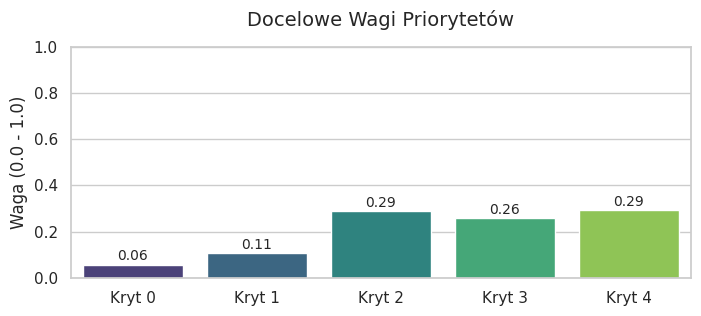

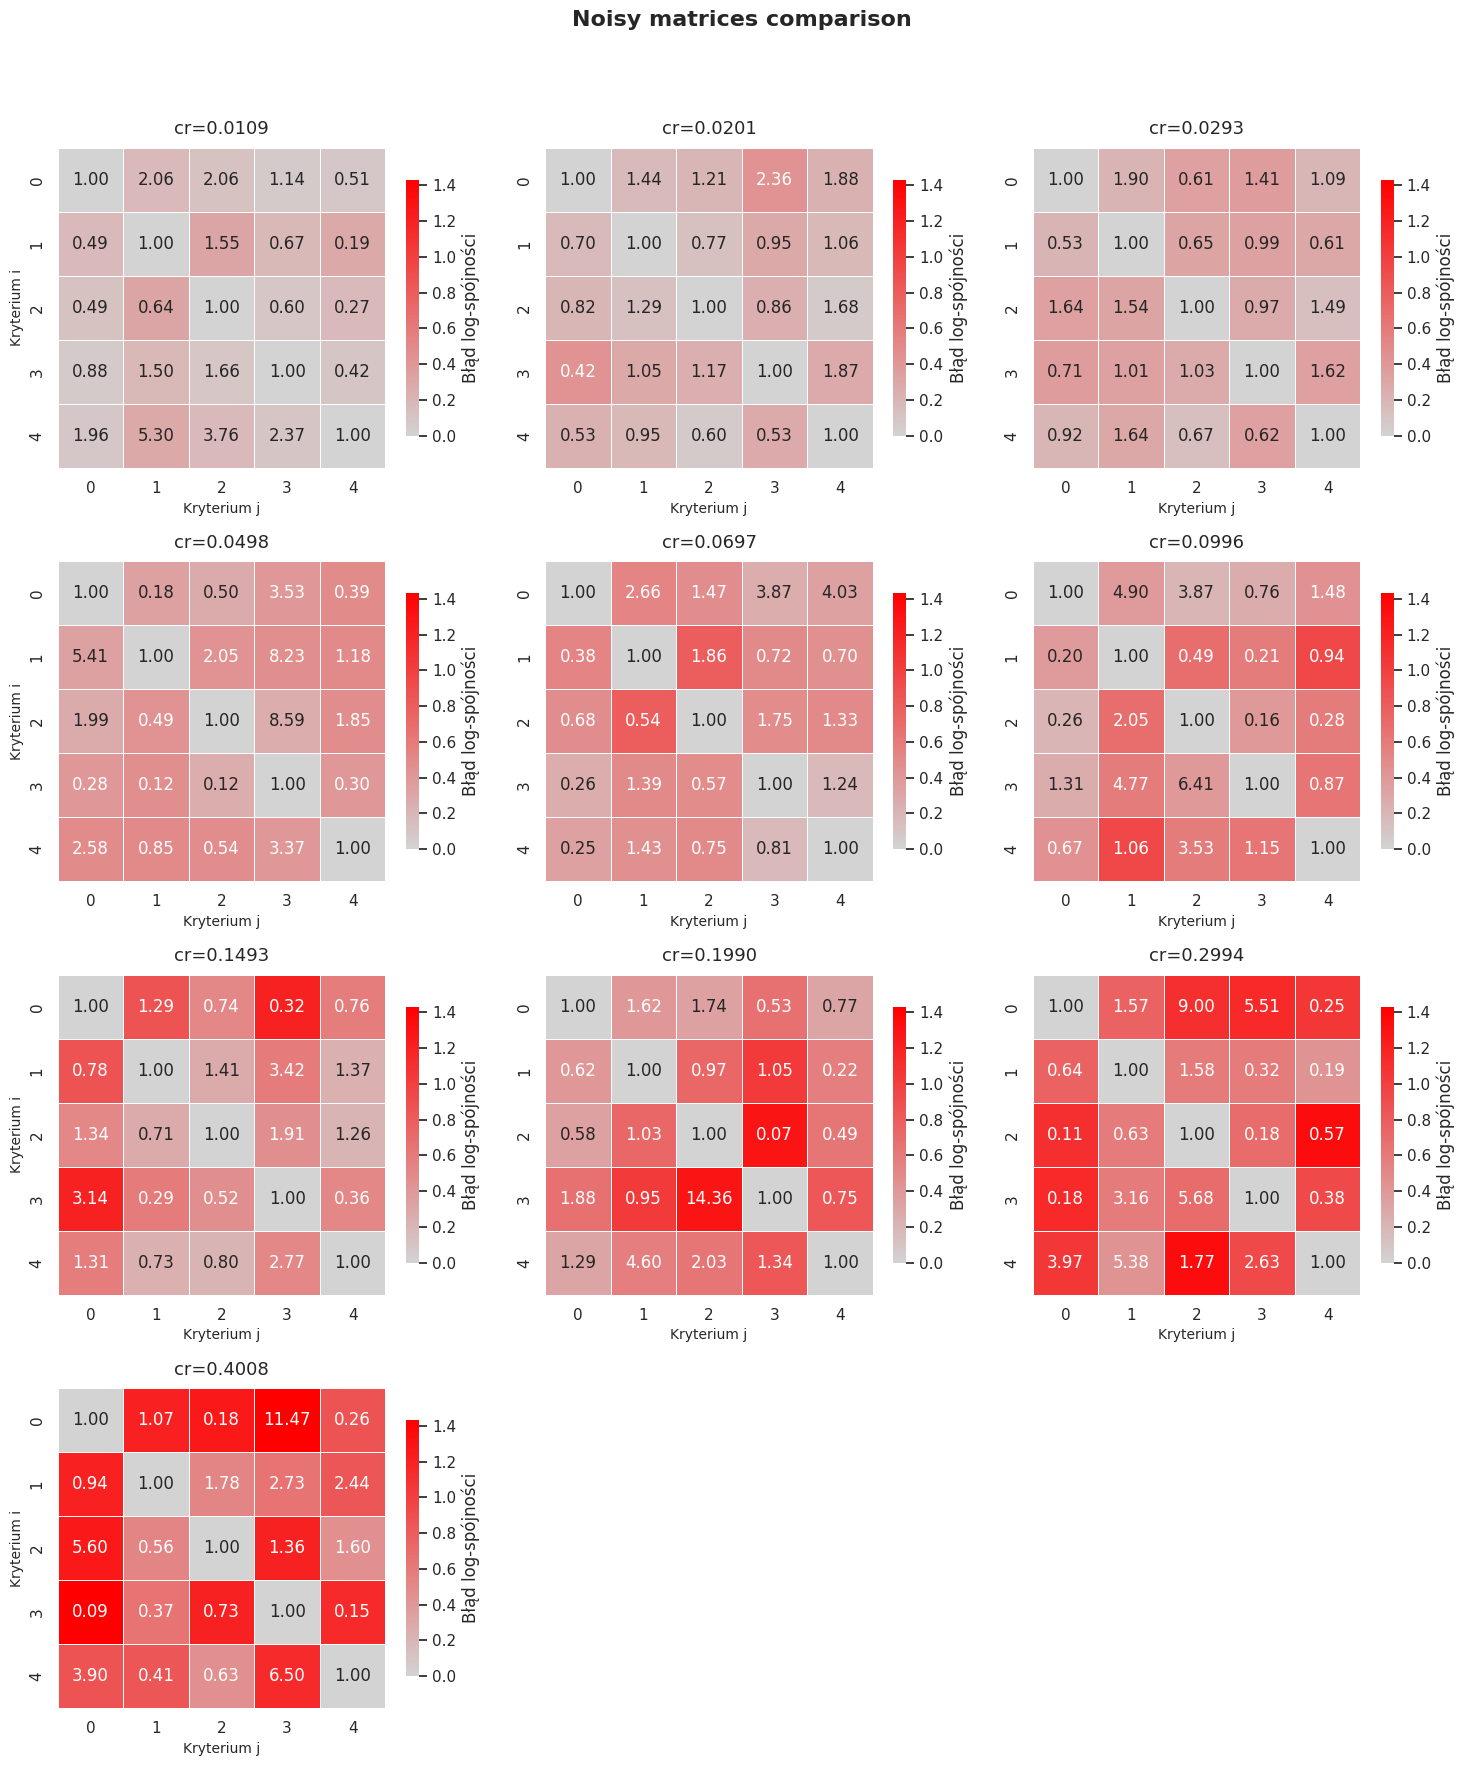

In [37]:
evm = EVM()

m_clean = matrix_coh[0]
m_noisy = matrix_noisy[0]
w_target = weights_coh[0]
consistency_ratios = []

for matrix in noisy_matrixes_list:
    w_noised_computed, consistency_ratio = evm.compute_single(matrix)
    consistency_ratios.append(consistency_ratio)

w_noised = weigths_noisy[0]

viz = MatricesVisualizator()

viz.plot_weights(w_target)
# viz.plot_weights_comparison(w_noised, w_noised_computed, consistency_ratio)
# viz.compare_matrices(m_clean, m_noisy, coherence_rate=consistency_ratio)
viz.noisy_matrices_comparison(noisy_matrixes_list, consistency_ratios)

Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c001).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c002).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c003).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c005).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c007).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c010).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c015).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c020).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c030).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c040).
[0.40077098 0.39935505 0.40056362 0.40092035 0.40052438 0.39948002
 0.39917501 0.39990479 0.40040684 0.40043542]
Średni CR w zbiorze: 0.400
Średni błąd MAE: 0.0748
Średnia korelacja Kendalla: 0.4200


/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/konrad/studia/semestr6/sieci_neuronowe/NN-preference-modeling/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


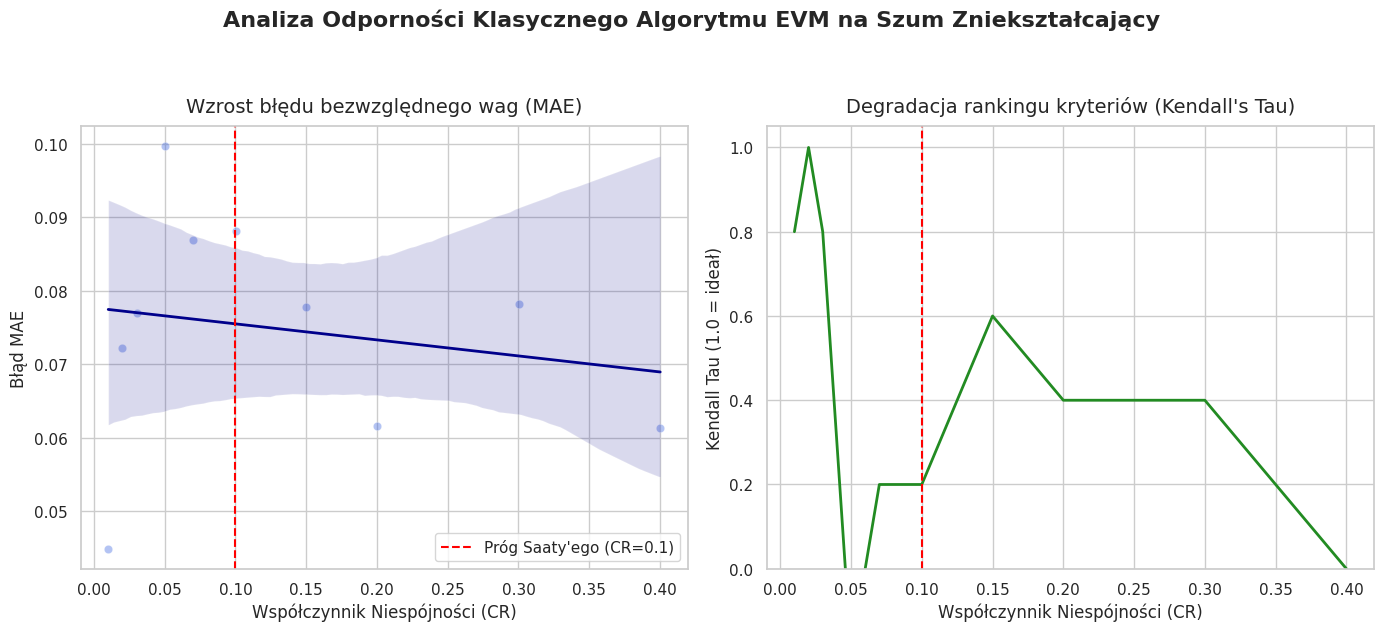

In [38]:
loader = DataLoader()
noisy_matrixes_list = []
noisy_weights_list = []
noisy_rates = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.4]

for level in noisy_rates:
    matrix_noisy, weigths_noisy = loader.load_noisy_matrices(level)
    noisy_matrixes_list.append(matrix_noisy)
    noisy_weights_list.append(weigths_noisy)


evm_solver = EVM()
evaluator = Evaluator()
mean_mae_errors = []
mean_kendal_taus = []
mean_cr_values = []
for batch_matrices, batch_weights in zip(noisy_matrixes_list, noisy_weights_list):
    evm_weights, cr_values = evm_solver.compute_batch(batch_matrices)

    mae_errors, kendall_taus = evaluator.evaluate_batch(batch_weights, evm_weights)
    mean_mae_errors.append(np.mean(mae_errors))
    mean_kendal_taus.append(np.mean(mean_kendal_taus))
    mean_cr_values.append(np.mean(cr_values))

print(cr_values)
print(f"Średni CR w zbiorze: {np.mean(cr_values):.3f}")
print(f"Średni błąd MAE: {np.mean(mae_errors):.4f}")
print(f"Średnia korelacja Kendalla: {np.mean(kendall_taus):.4f}")

viz = MatricesVisualizator()
viz.plot_evm_degradation(mean_cr_values, np.array(mae_errors), np.array(kendall_taus))

In [39]:
coherent_generator = CoherentMatricesGenerator(10, 5)
coherence_rates = [i/100 for i in range(1, 10)]
consistency_ratios = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.4]

matrix_coh, weights_coh = coherent_generator.generate()
coherent_generator.save()

for ratio in consistency_ratios:
    target_generator = TargetCRMatricesGenerator(10, 5, ratio, tolerance=0.001)

    matrix_noisy, weigths_noisy = target_generator.generate()
    target_generator.save()

Zapisano spójne macierze w: data/synthetic_data/coherent
Rozpoczynam generowanie 10 macierzy celując w CR = 0.01 (±0.001)...
Generowanie zakończone pomyślnie!
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Rozpoczynam generowanie 10 macierzy celując w CR = 0.02 (±0.001)...
Generowanie zakończone pomyślnie!
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Rozpoczynam generowanie 10 macierzy celując w CR = 0.03 (±0.001)...
Generowanie zakończone pomyślnie!
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Rozpoczynam generowanie 10 macierzy celując w CR = 0.05 (±0.001)...
Generowanie zakończone pomyślnie!
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Rozpoczynam generowanie 10 macierzy celując w CR = 0.07 (±0.001)...
Generowanie zakończone pomyślnie!
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Rozpoczynam generowanie 10 macierzy celując w CR = 0.1 (±0.001)...
Generowanie zakończone pomyślnie!
Zapisano zaszumione macierze w: data/synth

Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c001).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c002).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c003).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c005).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c007).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c010).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c015).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c020).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c030).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c040).

--- WYNIKI GLOBALNE EKSPERYMENTU ---
Przeanalizowano łącznie 100 macierzy.
Globalny średni CR: 0.1330
Globalny średni błąd MAE: 0.0432
Globalna średnia korelacja Kendalla: 0.6440


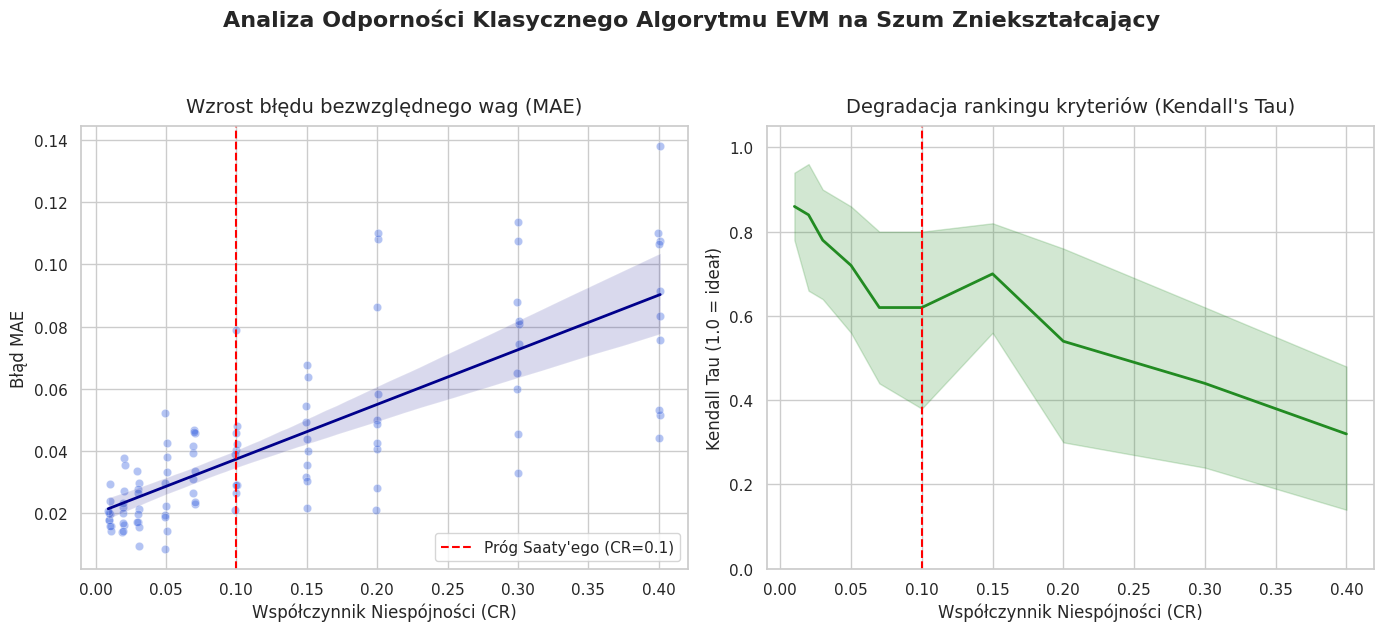

In [ ]:
noisy_matrices_list = []
noisy_weights_list = []
noisy_rates = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.4]

for level in noisy_rates:
    matrix_noisy, weights_noisy = loader.load_noisy_matrices(level)
    noisy_matrices_list.append(matrix_noisy)
    noisy_weights_list.append(weights_noisy)

all_mae_errors = []
all_kendall_taus = []
all_cr_values = []

for batch_matrices, batch_weights in zip(noisy_matrices_list, noisy_weights_list):
    evm_weights, cr_values = evm_solver.compute_batch(batch_matrices)
    mae_errors, kendall_taus = evaluator.evaluate_batch(batch_weights, evm_weights)

    all_cr_values.extend(cr_values)
    all_mae_errors.extend(mae_errors)
    all_kendall_taus.extend(kendall_taus)

all_cr_values = np.array(all_cr_values)
all_mae_errors = np.array(all_mae_errors)
all_kendall_taus = np.array(all_kendall_taus)

print("\n--- WYNIKI GLOBALNE EKSPERYMENTU ---")
print(f"Przeanalizowano łącznie {len(all_cr_values)} macierzy.")
print(f"Globalny średni CR: {np.mean(all_cr_values):.4f}")
print(f"Globalny średni błąd MAE: {np.mean(all_mae_errors):.4f}")
print(f"Globalna średnia korelacja Kendalla: {np.mean(all_kendall_taus):.4f}")

viz = MatricesVisualizator()
viz.plot_evm_degradation(all_cr_values, all_mae_errors, all_kendall_taus)